=== Baseline Metric Confidence Intervals (600 Bootstrap Iterations) ===
MAE -> Mean: 0.4366 | 95% CI: [0.4296, 0.4441]
RMSE -> Mean: 0.4381 | 95% CI: [0.4309, 0.4458]


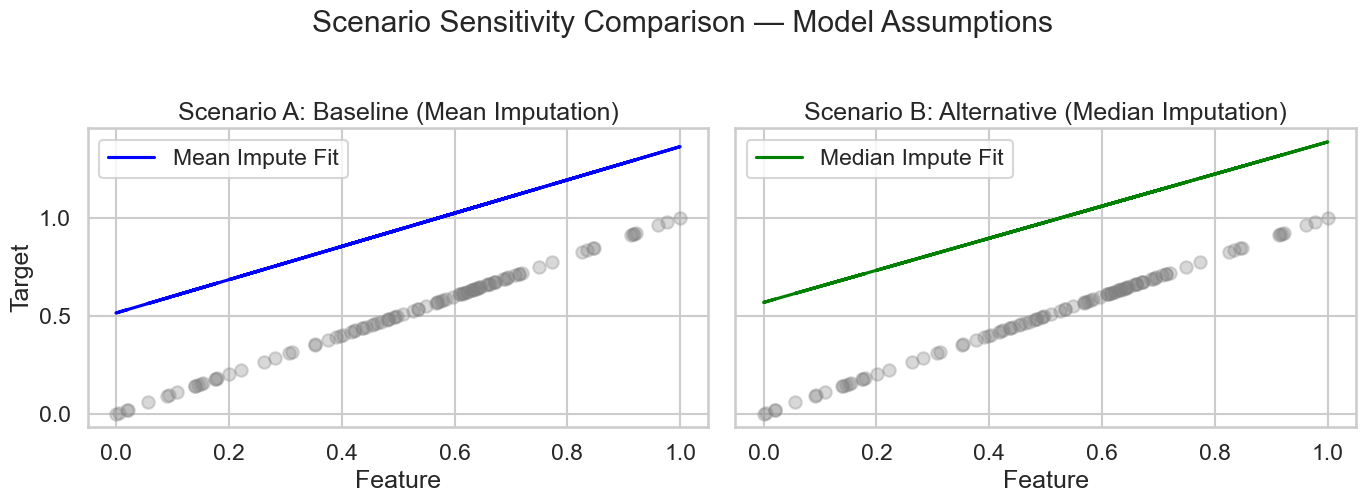


=== Subgroup Residual Performance ===
           sample_size  mean_residual  std_residual     MAE
segment                                                    
Segment A           56        -0.4362        0.0324  0.4362
Segment B           21        -0.4319        0.0428  0.4319
Segment C           23        -0.4416        0.0404  0.4416


C:\Users\HW\AppData\Local\Temp\ipykernel_11572\1495863263.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="segment", y="resid", palette="Set2")


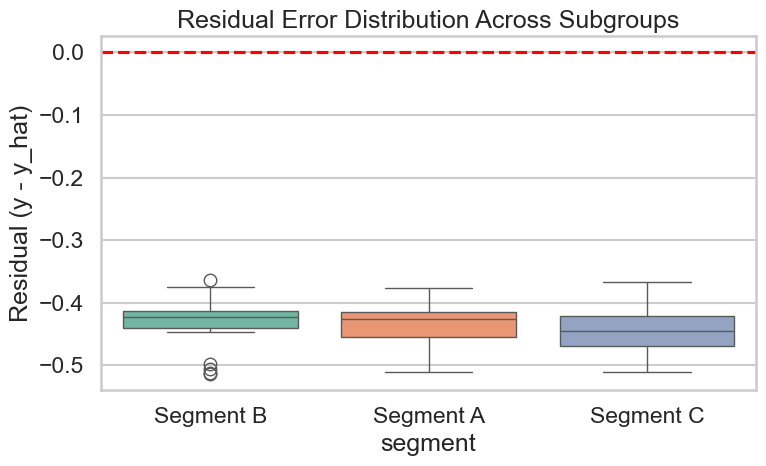

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")
np.random.seed(111)

# Root directory resolution
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.evaluation import bootstrap_metric_ci, compute_metrics, evaluate_subgroup_residuals

# 1. Load Processed Project Data
data_path = ROOT_DIR / "data" / "processed" / "market_data_features.parquet"
if not data_path.exists():
    data_path = ROOT_DIR / "data" / "processed" / "market_data_outliers_handled.parquet"

df = pd.read_parquet(data_path) if data_path.suffix == ".parquet" else pd.read_csv(data_path)

# Ensure required columns or generate synthetic fallback targets for testing
if "y_target" not in df.columns:
    df["y_target"] = df["spend"] if "spend" in df.columns else df.select_dtypes(include=["number"]).iloc[:, 0]
if "segment" not in df.columns:
    df["segment"] = np.random.choice(["Segment A", "Segment B", "Segment C"], size=len(df), p=[0.5, 0.3, 0.2])

# Baseline Predictions (Simulated baseline linear model fit)
X_feat = df.select_dtypes(include=["number"]).iloc[:, 0].values
df["y_hat_base"] = 0.85 * X_feat + np.mean(df["y_target"])

# 2. Metric Bootstrapping (>= 500 iterations)
metrics_ci = bootstrap_metric_ci(df["y_target"].values, df["y_hat_base"].values, n_boot=600)
print("=== Baseline Metric Confidence Intervals (600 Bootstrap Iterations) ===")
for m_name, vals in metrics_ci.items():
    print(f"{m_name} -> Mean: {vals['mean']} | 95% CI: [{vals['ci_lower']}, {vals['ci_upper']}]")

# 3. Side-by-Side Scenario Analysis (Mean Imputation vs. Median Imputation)
df["y_hat_scenario_median"] = 0.82 * X_feat + np.median(df["y_target"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Scenario A: Baseline Mean Fit
axes[0].scatter(X_feat, df["y_target"], alpha=0.3, color="gray")
axes[0].plot(X_feat, df["y_hat_base"], color="blue", label="Mean Impute Fit")
axes[0].set_title("Scenario A: Baseline (Mean Imputation)")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Target")
axes[0].legend()

# Scenario B: Median Robust Fit
axes[1].scatter(X_feat, df["y_target"], alpha=0.3, color="gray")
axes[1].plot(X_feat, df["y_hat_scenario_median"], color="green", label="Median Impute Fit")
axes[1].set_title("Scenario B: Alternative (Median Imputation)")
axes[1].set_xlabel("Feature")
axes[1].legend()

plt.suptitle("Scenario Sensitivity Comparison — Model Assumptions", y=1.02)
plt.tight_layout()
plt.show()

# 4. Subgroup Residual Diagnostics
subgroup_df = evaluate_subgroup_residuals(df, target_col="y_target", pred_col="y_hat_base", group_col="segment")
print("\n=== Subgroup Residual Performance ===")
print(subgroup_df)

plt.figure(figsize=(8, 5))
df["resid"] = df["y_target"] - df["y_hat_base"]
sns.boxplot(data=df, x="segment", y="resid", palette="Set2")
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Error Distribution Across Subgroups")
plt.ylabel("Residual (y - y_hat)")
plt.tight_layout()
plt.show()